# Announced clue number across a game's arc

How does the number a spymaster announces fall as its own words run out, and
does that depend on `sigma`?

**Why not randomly sample board states.** The words left late in a real game
are not a random subset of the nine. They are the ones that *resisted* being
clued -- the obvious pairings went first, and what remains is what nothing
connected. A board with five randomly chosen own words is an easier board
than one holding the five a real game failed to clue away. Panel 2 measures
that gap directly.

**The one rule change.** A miss ends the turn, exactly as in Codenames, but
never ends the *game*: neutral, opponent and assassin reveals are all
absorbed and play continues. That lets a single game trace the whole arc from
9 own words down to 1 instead of stopping at the first assassin. Nothing else
differs.

No LLM anywhere in this notebook -- it is free to re-run.

In [1]:
import sys, os, multiprocessing, time
from collections import defaultdict
from concurrent.futures import ProcessPoolExecutor
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "scratch" else Path.cwd()
os.chdir(ROOT)
sys.path[:0] = [str(ROOT), str(ROOT / "scratch")]

import numpy as np
import matplotlib.pyplot as plt
import clue_arc
from codenames.board import MAX_CLUE_NUMBER
from codenames.similarity import DEFAULT_CACHE_DIR

SIGMAS      = [0.25, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 6.0, 10.0]
SHIPPED     = 2.5                 # configs/spymasters.json
N_GAMES     = 100                 # per sigma
GUESSER     = "noisy_numberbatch" # same space the spymaster scores in
TWIN_SIGMAS = [1.0, 2.5, 4.0]     # panel 2 only
WORKERS     = os.cpu_count() or 8

# One pool for the whole notebook. Under "spawn" every worker re-imports numpy
# and torch, so a second pool would pay that 16-process startup twice. Workers
# pin torch to ONE thread: its 8 intra-op threads return only ~1.15x on this
# shape of work (604ms vs 526ms per clue search) while occupying 8 cores, so
# 16 single-threaded processes beat 2 eight-threaded ones by ~8x.
POOL = ProcessPoolExecutor(max_workers=WORKERS,
                           mp_context=multiprocessing.get_context("spawn"),
                           initializer=clue_arc.init,
                           initargs=(DEFAULT_CACHE_DIR,))

def run(fn, tasks, label=""):
    """Parallel map. chunksize amortises IPC for the many-small-tasks case
    (a twin is one ~0.6s clue search) while leaving whole games at chunksize 1,
    where uneven game lengths need fine-grained load balancing."""
    n = len(tasks)
    chunk = max(1, min(16, n // (WORKERS * 4))) if n > WORKERS * 8 else 1
    t0 = time.time()
    out = list(POOL.map(fn, tasks, chunksize=chunk))
    dt = time.time() - t0
    print(f"  {label}{n} tasks, chunksize {chunk}, {dt:.0f}s ({n/dt:.1f}/s across {WORKERS} workers)")
    return out

print(f"{len(SIGMAS)} sigmas x {N_GAMES} games, {WORKERS} workers, MAX_CLUE_NUMBER={MAX_CLUE_NUMBER}")

10 sigmas x 100 games, 16 workers, MAX_CLUE_NUMBER=4


## 1. Play the arcs

In [2]:
tasks = [(sg, seed, GUESSER) for sg in SIGMAS for seed in range(N_GAMES)]
rows = [r for batch in run(clue_arc.play_arc, tasks, "arcs: ") for r in batch]
print(f"{len(rows)} turns from {len(tasks)} games")

by = defaultdict(list)
for r in rows:
    by[(r["sigma"], r["own_before"])].append(r["k"])

def curve(sg):
    ns = sorted({n for (s, n) in by if s == sg}, reverse=True)
    m  = np.array([np.mean(by[(sg, n)]) for n in ns])
    se = np.array([np.std(by[(sg, n)], ddof=1)/np.sqrt(len(by[(sg, n)])) if len(by[(sg, n)]) > 1 else 0.0 for n in ns])
    cnt = np.array([len(by[(sg, n)]) for n in ns])
    return np.array(ns), m, se, cnt

print(f"\nmean announced k        turns observed")
print(f"{'sigma':>6} " + " ".join(f"{n:>5}" for n in range(9, 0, -1)) + "   " + " ".join(f"{n:>4}" for n in range(9, 0, -1)))
for sg in SIGMAS:
    ns, m, se, cnt = curve(sg)
    dm, dc = dict(zip(ns, m)), dict(zip(ns, cnt))
    print(f"{sg:>6} " + " ".join(f"{dm.get(n, float('nan')):>5.2f}" for n in range(9, 0, -1))
          + "   " + " ".join(f"{dc.get(n, 0):>4d}" for n in range(9, 0, -1)))

  arcs: 1000 tasks, chunksize 15, 1028s (1.0/s across 16 workers)
7571 turns from 1000 games

mean announced k        turns observed
 sigma     9     8     7     6     5     4     3     2     1      9    8    7    6    5    4    3    2    1
  0.25  4.00  4.00  4.00  4.00  3.79  3.14  2.90  2.00  1.00    100    3    4   11   85   14   20   56   43
   0.5  3.96  4.00  3.60  3.39  3.27  2.50  2.24  1.98  1.00    100    1    5   23   75    4   29   62   45
   1.0  3.70   nan  2.89  2.52  2.28  2.08  1.81  1.29  1.00    100    0    9   42   53   26   63   52   85
   1.5  2.86   nan  2.22  1.98  1.65  1.33  1.06  1.01  1.00    100    0   41   52   48   67   78   95   99
   2.0  2.26  1.12  1.52  1.15  1.06  1.01  1.00  1.01  1.00    100    8   71   65   90   94   99  100  100
   2.5  1.55  1.06  1.12  1.04  1.01  1.01  1.00  1.00  1.00    100   51   92   89   96   99   99  100  102
   3.0  1.19  1.02  1.01  1.03  1.01  1.00  1.00  1.00  1.00    100   83   96   99   97   99  100  100  116
   

## 2. The arc, one line per noise level

`sigma` is an **ordered** variable, so the lines take a single-hue sequential
ramp (light = low sigma, dark = high) rather than categorical colours --
cycling hues would imply the levels are unrelated categories. The shipped
value is drawn in an accent with a 95% band so it reads against the ramp.

Below `n = 4` the announced number is capped by `min(n, MAX_CLUE_NUMBER)`, so
that region is shaded: any fall there is mechanical, not a model decision.

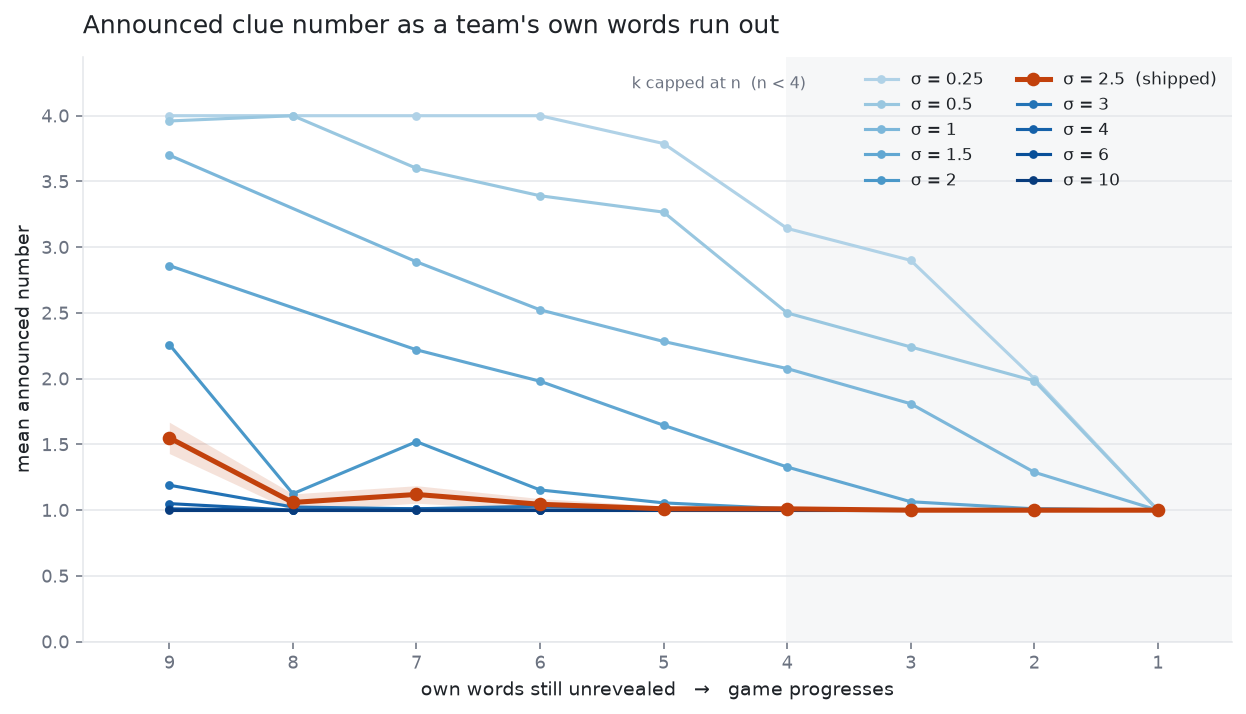

In [3]:
INK, MUTED, GRID, ACCENT = "#1F2328", "#6B7280", "#E5E7EB", "#C2410C"
ramp = plt.cm.Blues(np.linspace(0.32, 0.95, len(SIGMAS)))

fig, ax = plt.subplots(figsize=(9, 5.2), dpi=140)
ax.axvspan(0.4, MAX_CLUE_NUMBER, color="#F6F7F8", zorder=0)
ax.text(MAX_CLUE_NUMBER - 0.15, 4.3, f"k capped at n  (n < {MAX_CLUE_NUMBER})",
        ha="right", va="top", fontsize=8, color=MUTED)

for sg, c in zip(SIGMAS, ramp):
    ns, m, se, _ = curve(sg)
    hit = sg == SHIPPED
    ax.plot(ns, m, color=ACCENT if hit else c, lw=2.6 if hit else 1.6,
            marker="o", ms=6 if hit else 3.5, zorder=5 if hit else 3,
            label=f"σ = {sg:g}" + ("  (shipped)" if hit else ""))
    if hit:
        ax.fill_between(ns, m - 1.96*se, m + 1.96*se, color=ACCENT, alpha=0.15, lw=0, zorder=2)

ax.set_xlim(9.7, 0.4); ax.set_ylim(0, 4.45)
ax.set_xticks(range(9, 0, -1))
ax.set_xlabel("own words still unrevealed   →   game progresses", color=INK)
ax.set_ylabel("mean announced number", color=INK)
ax.set_title("Announced clue number as a team's own words run out",
             loc="left", fontsize=13, color=INK, pad=12)
ax.grid(axis="y", color=GRID, lw=0.8); ax.set_axisbelow(True)
for s_ in ("top", "right"): ax.spines[s_].set_visible(False)
for s_ in ("left", "bottom"): ax.spines[s_].set_color(GRID)
ax.tick_params(colors=MUTED, labelsize=9)
ax.legend(frameon=False, fontsize=8.5, ncol=2, loc="upper right", labelcolor=INK)
fig.tight_layout(); plt.show()

## 3. Does the selection effect exist?

The control: for each simulated turn, rebuild the **same board** with the
**same number of cards revealed per role** -- but randomly chosen ones. Same
words available, same counts gone; only *which* cards differ.

If the words a real game leaves behind are genuinely harder to clue, the
shuffled twin should support a **higher** announced number at the same
own-count.

  twins: 2248 tasks, chunksize 16, 305s (7.4/s across 16 workers)


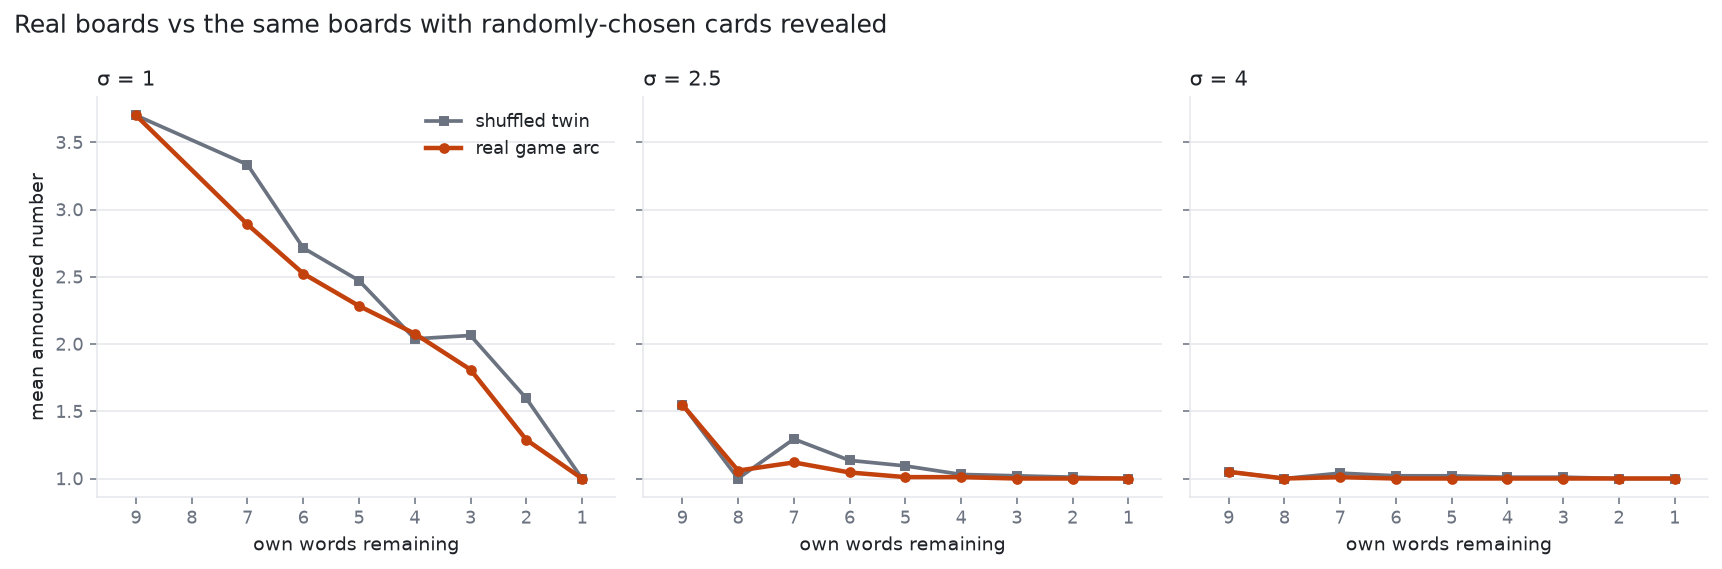

 sigma   n    real    twin  twin-real
   1.0   9    3.70    3.70      +0.00
   1.0   7    2.89    3.33      +0.44
   1.0   6    2.52    2.71      +0.19
   1.0   5    2.28    2.47      +0.19
   1.0   4    2.08    2.04      -0.04
   1.0   3    1.81    2.06      +0.25
   1.0   2    1.29    1.60      +0.31
   1.0   1    1.00    1.00      +0.00
   2.5   9    1.55    1.55      +0.00
   2.5   8    1.06    1.00      -0.06
   2.5   7    1.12    1.29      +0.17
   2.5   6    1.04    1.13      +0.09
   2.5   5    1.01    1.09      +0.08
   2.5   4    1.01    1.03      +0.02
   2.5   3    1.00    1.02      +0.02
   2.5   2    1.00    1.01      +0.01
   2.5   1    1.00    1.00      +0.00
   4.0   9    1.05    1.05      +0.00
   4.0   8    1.00    1.00      +0.00
   4.0   7    1.01    1.04      +0.03
   4.0   6    1.00    1.02      +0.02
   4.0   5    1.00    1.02      +0.02
   4.0   4    1.00    1.01      +0.01
   4.0   3    1.00    1.01      +0.01
   4.0   2    1.00    1.00      +0.00
   4.0   1  

In [4]:
twin_tasks, real_ks = [], []
for i, r in enumerate(rows):
    if r["sigma"] in TWIN_SIGMAS:
        twin_tasks.append((r["sigma"], r["seed"], r["revealed_by_role"], i))
        real_ks.append((r["sigma"], r["own_before"], r["k"]))
twins = run(clue_arc.shuffled_twin, twin_tasks, "twins: ")

real_by, twin_by = defaultdict(list), defaultdict(list)
for (sg, n, k), t in zip(real_ks, twins):
    if t is None: continue
    real_by[(sg, n)].append(k)
    twin_by[(sg, t["own_before"])].append(t["k"])

fig, axes = plt.subplots(1, len(TWIN_SIGMAS), figsize=(4.1*len(TWIN_SIGMAS), 4.1), dpi=140, sharey=True)
axes = np.atleast_1d(axes)
for ax, sg in zip(axes, TWIN_SIGMAS):
    ns = sorted({n for (s, n) in real_by if s == sg}, reverse=True)
    rm = [np.mean(real_by[(sg, n)]) for n in ns]
    tm = [np.mean(twin_by[(sg, n)]) if twin_by[(sg, n)] else np.nan for n in ns]
    ax.plot(ns, tm, color=MUTED, lw=1.9, marker="s", ms=4, label="shuffled twin")
    ax.plot(ns, rm, color=ACCENT, lw=2.3, marker="o", ms=4.5, label="real game arc")
    ax.set_xlim(9.7, 0.4); ax.set_xticks(range(9, 0, -1))
    ax.set_title(f"σ = {sg:g}", loc="left", fontsize=11, color=INK)
    ax.grid(axis="y", color=GRID, lw=0.8); ax.set_axisbelow(True)
    for s_ in ("top", "right"): ax.spines[s_].set_visible(False)
    for s_ in ("left", "bottom"): ax.spines[s_].set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.set_xlabel("own words remaining", color=INK)
axes[0].set_ylabel("mean announced number", color=INK)
axes[0].legend(frameon=False, fontsize=9, labelcolor=INK)
fig.suptitle("Real boards vs the same boards with randomly-chosen cards revealed",
             x=0.004, ha="left", fontsize=13, color=INK)
fig.tight_layout(); plt.show()

print(f"{'sigma':>6} {'n':>3} {'real':>7} {'twin':>7} {'twin-real':>10}")
for sg in TWIN_SIGMAS:
    for n in sorted({n for (s, n) in real_by if s == sg}, reverse=True):
        if not twin_by[(sg, n)]: continue
        r_, t_ = np.mean(real_by[(sg, n)]), np.mean(twin_by[(sg, n)])
        print(f"{sg:>6} {n:>3} {r_:>7.2f} {t_:>7.2f} {t_-r_:>+10.2f}")

## Notes

- **The guesser is `noisy_numberbatch`**, the same embedding space the
  spymaster scores in -- a near-perfect listener (~99.9% own-word rate,
  measured in `docs/log.md`). Deliberate here: it keeps guesser error out of
  the arc so what moves is the board, not the listener. It also means these
  games run cleaner than real ones.
- **Coverage per `n` is uneven by construction.** A team announcing 3 steps
  from 9 own words straight to 6 and never visits 8 or 7 that game, so low
  sigma has thin coverage mid-axis. The turn counts are printed beside the
  means -- check them before reading much into a single point.
- The shaded region below `n = 4` is where `min(n, MAX_CLUE_NUMBER)` binds.

In [5]:
POOL.shutdown()